In [ ]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import math
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("Libraries imported successfully!")

Using device: cuda
Libraries imported successfully!


Failed to download (trying next):
HTTP Error 404: Not Found

Failed to download (trying next):
HTTP Error 404: Not Found



Failed to download (trying next):
HTTP Error 404: Not Found

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:02<00:00, 4709248.79it/s]



Failed to download (trying next):
HTTP Error 404: Not Found

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:02<00:00, 4709248.79it/s]



...

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:01<00:00, 1299837.87it/s]



Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 4383462.67it/s]



Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Training samples: 60000
Test samples: 10000
Batch size: 64
Training batches: 938
Test batches: 157


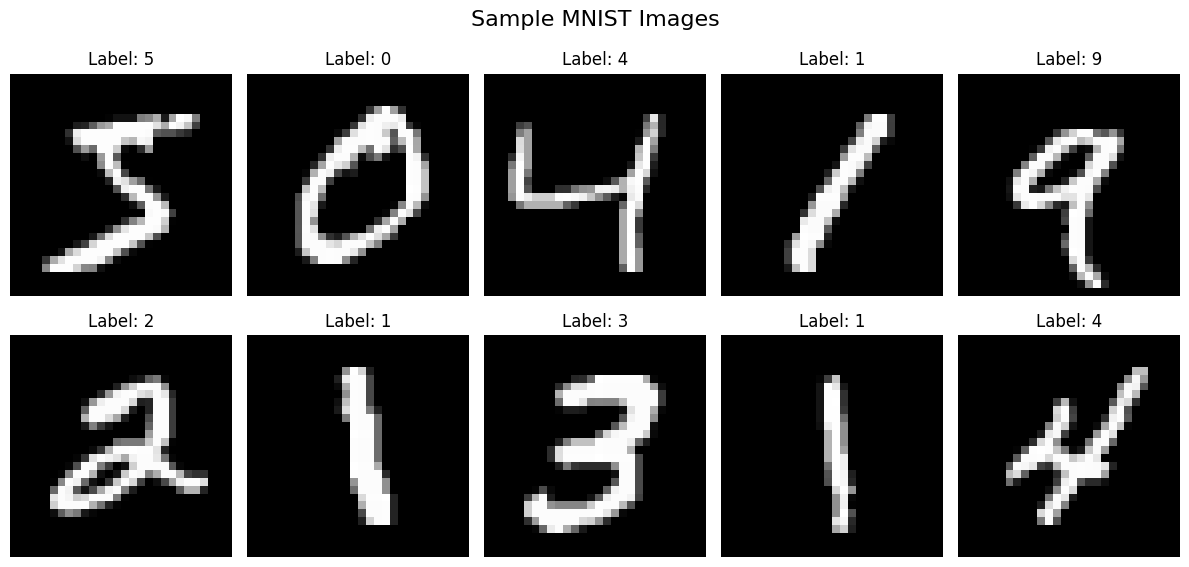

In [ ]:
# Load and Preprocess MNIST Dataset
# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Load MNIST dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

# Create data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Visualize some sample images
def show_mnist_samples(dataset, num_samples=10):
    """Display sample MNIST images"""
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    fig.suptitle('Sample MNIST Images', fontsize=16)

    for i in range(num_samples):
        image, label = dataset[i]
        row = i // 5
        col = i % 5

        # Denormalize for display
        image = image.squeeze() * 0.3081 + 0.1307

        axes[row, col].imshow(image, cmap='gray')
        axes[row, col].set_title(f'Label: {label}')
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

show_mnist_samples(train_dataset)

In [ ]:
# Create Vision Transformer Model
class PatchEmbedding(nn.Module):
    """Convert image to patches and embed them"""
    def __init__(self, img_size=28, patch_size=4, in_channels=1, embed_dim=64):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # Linear projection of flattened patches
        self.projection = nn.Linear(patch_size * patch_size * in_channels, embed_dim)

    def forward(self, x):
        # x: (batch_size, channels, height, width)
        batch_size = x.shape[0]

        # Reshape to patches
        # (batch_size, channels, height, width) -> (batch_size, num_patches, patch_size^2 * channels)
        x = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size) #Unfolds dimension 2&3 (height&width) into patches (batch_size, channels, number of patch rows, number of path columns, path_size, patch_size)
        x = x.contiguous().view(batch_size, self.num_patches, -1) #(batch_size, num_patches, input_features)

        # Project patches to embedding dimension
        x = self.projection(x) # (batch_size, num_patches, embed_dim)
        return x

class PositionalEncoding(nn.Module):
    """Add positional information to patch embeddings"""
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim)) #learned positional encoding

    def forward(self, x):
        return x + self.pos_embedding

class MultiHeadAttention(nn.Module):
    """Multi-head self-attention mechanism"""
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.attention_dropout = nn.Dropout(dropout)
        self.output_projection = nn.Linear(embed_dim, embed_dim)
        self.output_dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, seq_len, embed_dim = x.shape

        # Generate Q, K, V
        qkv = self.qkv(x).reshape(batch_size, seq_len, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, batch_size, num_heads, seq_len, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Attention scores
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.attention_dropout(attention_weights)

        # Apply attention to values
        attention_output = torch.matmul(attention_weights, v)
        attention_output = attention_output.transpose(1, 2).reshape(batch_size, seq_len, embed_dim)

        # Output projection
        output = self.output_projection(attention_output)
        output = self.output_dropout(output)

        return output, attention_weights

class TransformerEncoderBlock(nn.Module):
    """Single transformer encoder block"""
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.layer_norm2 = nn.LayerNorm(embed_dim)

        # MLP block
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # Self-attention with residual connection
        attention_output, attention_weights = self.attention(self.layer_norm1(x))
        x = x + attention_output

        # MLP with residual connection
        mlp_output = self.mlp(self.layer_norm2(x))
        x = x + mlp_output

        return x, attention_weights

class VisionTransformer(nn.Module):
    """Vision Transformer for MNIST classification"""
    def __init__(self, img_size=28, patch_size=4, in_channels=1, num_classes=10,
                 embed_dim=64, num_heads=4, num_layers=4, mlp_dim=128, dropout=0.1):
        super().__init__()

        self.patch_embedding = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embedding.num_patches

        # Class token
        self.class_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        # Positional encoding
        self.pos_encoding = PositionalEncoding(num_patches, embed_dim)

        # Transformer encoder blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])

        # Layer normalization
        self.layer_norm = nn.LayerNorm(embed_dim)

        # Classification head
        self.classification_head = nn.Linear(embed_dim, num_classes)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size = x.shape[0]

        # Patch embedding
        x = self.patch_embedding(x)  # (batch_size, num_patches, embed_dim)

        # Add class token to interact with all other patch tokens, learning to gather summary information from the entire image for classification prediction
        class_tokens = self.class_token.expand(batch_size, -1, -1)
        x = torch.cat((class_tokens, x), dim=1)  # (batch_size, num_patches + 1, embed_dim)

        # Add positional encoding
        x = self.pos_encoding(x)
        x = self.dropout(x)

        # Pass through transformer blocks
        attention_weights_list = []
        for transformer_block in self.transformer_blocks:
            x, attention_weights = transformer_block(x)
            attention_weights_list.append(attention_weights)

        # Layer normalization
        x = self.layer_norm(x)

        # Use class token for classification
        class_token_output = x[:, 0]  # First token is class token

        # Classification
        logits = self.classification_head(class_token_output)

        return logits, attention_weights_list

# Create model
model = VisionTransformer(
    img_size=28,
    patch_size=4,
    in_channels=1,
    num_classes=10,
    embed_dim=64,
    num_heads=4,
    num_layers=4,
    mlp_dim=128,
    dropout=0.1
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Vision Transformer created successfully!")
print(f"Total parameters: {total_params:,}")
print(f"Image size: 28x28")
print(f"Patch size: 4x4")
print(f"Number of patches: {(28//4)**2}")
print(f"Embedding dimension: 64")
print(f"Number of transformer layers: 4")
print(f"Number of attention heads: 4")

# Test forward pass
test_input = torch.randn(2, 1, 28, 28).to(device)
with torch.no_grad():
    output, attention_weights = model(test_input)
    print(f"\nTest input shape: {test_input.shape}")
    print(f"Test output shape: {output.shape}")
    print(f"Number of attention weight matrices: {len(attention_weights)}")

Vision Transformer created successfully!
Total parameters: 139,018
Image size: 28x28
Patch size: 4x4
Number of patches: 49
Embedding dimension: 64
Number of transformer layers: 4
Number of attention heads: 4

Test input shape: torch.Size([2, 1, 28, 28])
Test output shape: torch.Size([2, 10])
Number of attention weight matrices: 4


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from timm.models.layers import trunc_normal_, DropPath
from timm.models.registry import register_model

class Block(nn.Module):
    r""" ConvNeXt Block. There are two equivalent implementations:
    (1) DwConv -> LayerNorm (channels_first) -> 1x1 Conv -> GELU -> 1x1 Conv; all in (N, C, H, W)
    (2) DwConv -> Permute to (N, H, W, C); LayerNorm (channels_last) -> Linear -> GELU -> Linear; Permute back
    We use (2) as we find it slightly faster in PyTorch

    Args:
        dim (int): Number of input channels.
        drop_path (float): Stochastic depth rate. Default: 0.0
        layer_scale_init_value (float): Init value for Layer Scale. Default: 1e-6.
    """
    def __init__(self, dim, drop_path=0., layer_scale_init_value=1e-6):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim) # depthwise conv
        self.norm = LayerNorm(dim, eps=1e-6)
        self.pwconv1 = nn.Linear(dim, 4 * dim) # pointwise/1x1 convs, implemented with linear layers
        self.act = nn.GELU()
        self.pwconv2 = nn.Linear(4 * dim, dim)
        self.gamma = nn.Parameter(layer_scale_init_value * torch.ones((dim)),
                                    requires_grad=True) if layer_scale_init_value > 0 else None
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()

    def forward(self, x):
        input = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1) # (N, C, H, W) -> (N, H, W, C)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        if self.gamma is not None:
            x = self.gamma * x
        x = x.permute(0, 3, 1, 2) # (N, H, W, C) -> (N, C, H, W)

        x = input + self.drop_path(x)
        return x

class ConvNeXt(nn.Module):
    r""" ConvNeXt
        A PyTorch impl of : `A ConvNet for the 2020s`  -
          https://arxiv.org/pdf/2201.03545.pdf

    Args:
        in_chans (int): Number of input image channels. Default: 3
        num_classes (int): Number of classes for classification head. Default: 1000
        depths (tuple(int)): Number of blocks at each stage. Default: [3, 3, 9, 3]
        dims (int): Feature dimension at each stage. Default: [96, 192, 384, 768]
        drop_path_rate (float): Stochastic depth rate. Default: 0.
        layer_scale_init_value (float): Init value for Layer Scale. Default: 1e-6.
        head_init_scale (float): Init scaling value for classifier weights and biases. Default: 1.
    """
    def __init__(self, in_chans=3, num_classes=1000,
                 depths=[3, 3, 9, 3], dims=[96, 192, 384, 768], drop_path_rate=0.,
                 layer_scale_init_value=1e-6, head_init_scale=1.,
                 ):
        super().__init__()

        self.downsample_layers = nn.ModuleList() # stem and 3 intermediate downsampling conv layers
        stem = nn.Sequential(
            nn.Conv2d(in_chans, dims[0], kernel_size=4, stride=4),
            LayerNorm(dims[0], eps=1e-6, data_format="channels_first")
        )
        self.downsample_layers.append(stem)
        for i in range(3):
            downsample_layer = nn.Sequential(
                    LayerNorm(dims[i], eps=1e-6, data_format="channels_first"),
                    nn.Conv2d(dims[i], dims[i+1], kernel_size=2, stride=2),
            )
            self.downsample_layers.append(downsample_layer)

        self.stages = nn.ModuleList() # 4 feature resolution stages, each consisting of multiple residual blocks
        dp_rates=[x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]
        cur = 0
        for i in range(4):
            stage = nn.Sequential(
                *[Block(dim=dims[i], drop_path=dp_rates[cur + j],
                layer_scale_init_value=layer_scale_init_value) for j in range(depths[i])]
            )
            self.stages.append(stage)
            cur += depths[i]

        self.norm = nn.LayerNorm(dims[-1], eps=1e-6) # final norm layer
        self.head = nn.Linear(dims[-1], num_classes)

        self.apply(self._init_weights)
        self.head.weight.data.mul_(head_init_scale)
        self.head.bias.data.mul_(head_init_scale)

    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            trunc_normal_(m.weight, std=.02)
            nn.init.constant_(m.bias, 0)

    def forward_features(self, x):
        for i in range(4):
            x = self.downsample_layers[i](x)
            x = self.stages[i](x)
        return self.norm(x.mean([-2, -1])) # global average pooling, (N, C, H, W) -> (N, C)

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x

class LayerNorm(nn.Module):
    r""" LayerNorm that supports two data formats: channels_last (default) or channels_first.
    The ordering of the dimensions in the inputs. channels_last corresponds to inputs with
    shape (batch_size, height, width, channels) while channels_first corresponds to inputs
    with shape (batch_size, channels, height, width).
    """
    def __init__(self, normalized_shape, eps=1e-6, data_format="channels_last"):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.data_format = data_format
        if self.data_format not in ["channels_last", "channels_first"]:
            raise NotImplementedError
        self.normalized_shape = (normalized_shape, )

    def forward(self, x):
        if self.data_format == "channels_last":
            return F.layer_norm(x, self.normalized_shape, self.weight, self.bias, self.eps)
        elif self.data_format == "channels_first":
            u = x.mean(1, keepdim=True)
            s = (x - u).pow(2).mean(1, keepdim=True)
            x = (x - u) / torch.sqrt(s + self.eps)
            x = self.weight[:, None, None] * x + self.bias[:, None, None]
            return x


model_urls = {
    "convnext_tiny_1k": "https://dl.fbaipublicfiles.com/convnext/convnext_tiny_1k_224_ema.pth",
    "convnext_small_1k": "https://dl.fbaipublicfiles.com/convnext/convnext_small_1k_224_ema.pth",
    "convnext_base_1k": "https://dl.fbaipublicfiles.com/convnext/convnext_base_1k_224_ema.pth",
    "convnext_large_1k": "https://dl.fbaipublicfiles.com/convnext/convnext_large_1k_224_ema.pth",
    "convnext_tiny_22k": "https://dl.fbaipublicfiles.com/convnext/convnext_tiny_22k_224.pth",
    "convnext_small_22k": "https://dl.fbaipublicfiles.com/convnext/convnext_small_22k_224.pth",
    "convnext_base_22k": "https://dl.fbaipublicfiles.com/convnext/convnext_base_22k_224.pth",
    "convnext_large_22k": "https://dl.fbaipublicfiles.com/convnext/convnext_large_22k_224.pth",
    "convnext_xlarge_22k": "https://dl.fbaipublicfiles.com/convnext/convnext_xlarge_22k_224.pth",
}

@register_model
def convnext_tiny(pretrained=False,in_22k=False, **kwargs):
    model = ConvNeXt(depths=[3, 3, 9, 3], dims=[96, 192, 384, 768], **kwargs)
    if pretrained:
        url = model_urls['convnext_tiny_22k'] if in_22k else model_urls['convnext_tiny_1k']
        checkpoint = torch.hub.load_state_dict_from_url(url=url, map_location="cpu", check_hash=True)
        model.load_state_dict(checkpoint["model"])
    return model

@register_model
def convnext_small(pretrained=False,in_22k=False, **kwargs):
    model = ConvNeXt(depths=[3, 3, 27, 3], dims=[96, 192, 384, 768], **kwargs)
    if pretrained:
        url = model_urls['convnext_small_22k'] if in_22k else model_urls['convnext_small_1k']
        checkpoint = torch.hub.load_state_dict_from_url(url=url, map_location="cpu")
        model.load_state_dict(checkpoint["model"])
    return model

@register_model
def convnext_base(pretrained=False, in_22k=False, **kwargs):
    model = ConvNeXt(depths=[3, 3, 27, 3], dims=[128, 256, 512, 1024], **kwargs)
    if pretrained:
        url = model_urls['convnext_base_22k'] if in_22k else model_urls['convnext_base_1k']
        checkpoint = torch.hub.load_state_dict_from_url(url=url, map_location="cpu")
        model.load_state_dict(checkpoint["model"])
    return model

@register_model
def convnext_large(pretrained=False, in_22k=False, **kwargs):
    model = ConvNeXt(depths=[3, 3, 27, 3], dims=[192, 384, 768, 1536], **kwargs)
    if pretrained:
        url = model_urls['convnext_large_22k'] if in_22k else model_urls['convnext_large_1k']
        checkpoint = torch.hub.load_state_dict_from_url(url=url, map_location="cpu")
        model.load_state_dict(checkpoint["model"])
    return model

@register_model
def convnext_xlarge(pretrained=False, in_22k=False, **kwargs):
    model = ConvNeXt(depths=[3, 3, 27, 3], dims=[256, 512, 1024, 2048], **kwargs)
    if pretrained:
        assert in_22k, "only ImageNet-22K pre-trained ConvNeXt-XL is available; please set in_22k=True"
        url = model_urls['convnext_xlarge_22k']
        checkpoint = torch.hub.load_state_dict_from_url(url=url, map_location="cpu")
        model.load_state_dict(checkpoint["model"])
    return model

In [ ]:
def convnext_tiny_mnist(num_classes=10):
    # Create base ConvNeXt Tiny
    model = ConvNeXt(
        in_chans=1,                # MNIST has 1 input channel
        num_classes=num_classes,   # 10 digits
        depths=[3, 3, 9, 3],
        dims=[96, 192, 384, 768],
        drop_path_rate=0.0
    )
    return model


Sample image label: 5


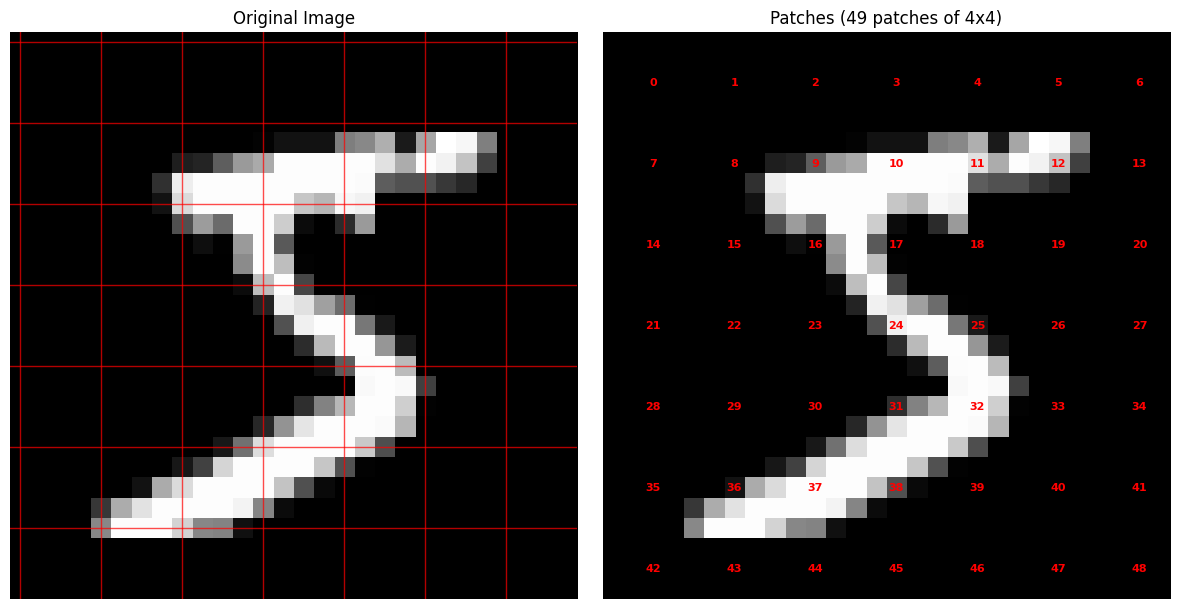

Number of patches extracted: 49
Each patch size: torch.Size([4, 4])

Patch Embedding Test:
Input shape: torch.Size([4, 1, 28, 28])
Output shape: torch.Size([4, 49, 64])
Number of patches: 49
Embedding dimension: 64


In [ ]:
# Prepare Data for Transformer and Visualize Patches
def visualize_patches(image, patch_size=4):
    """Visualize how an image is divided into patches"""
    # Denormalize image for visualization
    image = image.squeeze() * 0.3081 + 0.1307

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Original image
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Draw patch boundaries
    height, width = image.shape
    for i in range(0, height, patch_size):
        axes[0].axhline(i, color='red', linewidth=1, alpha=0.7)
    for j in range(0, width, patch_size):
        axes[0].axvline(j, color='red', linewidth=1, alpha=0.7)

    # Extract and display patches
    num_patches_per_side = height // patch_size
    patches = []

    for i in range(num_patches_per_side):
        for j in range(num_patches_per_side):
            patch = image[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size]
            patches.append(patch)

    # Display patches
    patch_grid = np.zeros((num_patches_per_side * patch_size, num_patches_per_side * patch_size))
    for idx, patch in enumerate(patches):
        i = idx // num_patches_per_side
        j = idx % num_patches_per_side
        patch_grid[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size] = patch

    axes[1].imshow(patch_grid, cmap='gray')
    axes[1].set_title(f'Patches ({len(patches)} patches of {patch_size}x{patch_size})')
    axes[1].axis('off')

    # Add patch numbers
    for idx in range(len(patches)):
        i = idx // num_patches_per_side
        j = idx % num_patches_per_side
        y = i * patch_size + patch_size // 2
        x = j * patch_size + patch_size // 2
        axes[1].text(x, y, str(idx), ha='center', va='center',
                    color='red', fontsize=8, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return patches

# Visualize patch extraction
sample_image, sample_label = train_dataset[0]
print(f"Sample image label: {sample_label}")
patches = visualize_patches(sample_image, patch_size=4)
print(f"Number of patches extracted: {len(patches)}")
print(f"Each patch size: {patches[0].shape}")

# Test patch embedding
def test_patch_embedding():
    """Test the patch embedding process"""
    patch_embed = PatchEmbedding(img_size=28, patch_size=4, in_channels=1, embed_dim=64)

    # Test with a batch of images
    test_batch = torch.randn(4, 1, 28, 28)
    embedded_patches = patch_embed(test_batch)

    print(f"\nPatch Embedding Test:")
    print(f"Input shape: {test_batch.shape}")
    print(f"Output shape: {embedded_patches.shape}")
    print(f"Number of patches: {patch_embed.num_patches}")
    print(f"Embedding dimension: 64")

    return embedded_patches

embedded_patches = test_patch_embedding()

In [ ]:
# Train the Model
# Training configuration
num_epochs = 20
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Lists to store training history
train_losses = []
train_accuracies = []
test_accuracies = []

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc='Training')
    for batch_idx, (data, targets) in enumerate(progress_bar):
        data, targets = data.to(device), targets.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs, _ = model(data)
        loss = criterion(outputs, targets)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        # Update progress bar
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

def test_epoch(model, test_loader, criterion, device):
    """Evaluate on test set"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            outputs, _ = model(data)
            loss = criterion(outputs, targets)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    avg_loss = total_loss / len(test_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

# Training loop
print("🚀 Starting Vision Transformer Training!")
print("=" * 60)

best_test_acc = 0.0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 30)

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Test
    test_loss, test_acc = test_epoch(model, test_loader, criterion, device)

    # Store history
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # Print epoch results
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

    # Save best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'best_vit_mnist.pth')
        print(f"✅ New best test accuracy: {best_test_acc:.2f}%")

print(f"\n🎉 Training completed!")
print(f"Best test accuracy: {best_test_acc:.2f}%")

🚀 Starting Vision Transformer Training!

Epoch 1/20
------------------------------


Training: 100%|██████████| 938/938 [00:19<00:00, 49.16it/s, Loss=0.1999, Acc=82.76%]


Train Loss: 0.5306 | Train Acc: 82.76%
Test Loss: 0.1835 | Test Acc: 94.25%
✅ New best test accuracy: 94.25%

Epoch 2/20
------------------------------


Training: 100%|██████████| 938/938 [00:20<00:00, 45.14it/s, Loss=0.3661, Acc=93.25%]


Train Loss: 0.2157 | Train Acc: 93.25%
Test Loss: 0.1161 | Test Acc: 96.34%
✅ New best test accuracy: 96.34%

Epoch 3/20
------------------------------


...

Train Loss: 0.0554 | Train Acc: 98.17%
Test Loss: 0.0528 | Test Acc: 98.38%

Epoch 19/20
------------------------------


Training: 100%|██████████| 938/938 [00:16<00:00, 56.85it/s, Loss=0.0789, Acc=98.25%]


Train Loss: 0.0520 | Train Acc: 98.25%
Test Loss: 0.0508 | Test Acc: 98.38%

Epoch 20/20
------------------------------


Training: 100%|██████████| 938/938 [00:17<00:00, 54.09it/s, Loss=0.0053, Acc=98.35%]


Train Loss: 0.0509 | Train Acc: 98.35%
Test Loss: 0.0492 | Test Acc: 98.55%
✅ New best test accuracy: 98.55%

🎉 Training completed!
Best test accuracy: 98.55%


In [ ]:
# Evaluate Model Performance
# Load best model
model.load_state_dict(torch.load('best_vit_mnist.pth'))

# Detailed evaluation
def detailed_evaluation(model, test_loader, device):
    """Perform detailed evaluation with per-class metrics"""
    model.eval()
    all_predictions = []
    all_targets = []
    all_probabilities = []

    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            outputs, _ = model(data)
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    return np.array(all_predictions), np.array(all_targets), np.array(all_probabilities)

print("📊 Detailed Model Evaluation")
print("=" * 40)

predictions, targets, probabilities = detailed_evaluation(model, test_loader, device)

# Overall accuracy
accuracy = (predictions == targets).mean() * 100
print(f"Overall Test Accuracy: {accuracy:.2f}%")

# Classification report
print("\n📋 Classification Report:")
print(classification_report(targets, predictions, target_names=[str(i) for i in range(10)]))

print(f"\n✅ Evaluation completed!")

📊 Detailed Model Evaluation
Overall Test Accuracy: 98.55%

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.97      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.97      0.98      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


✅ Evaluation completed!


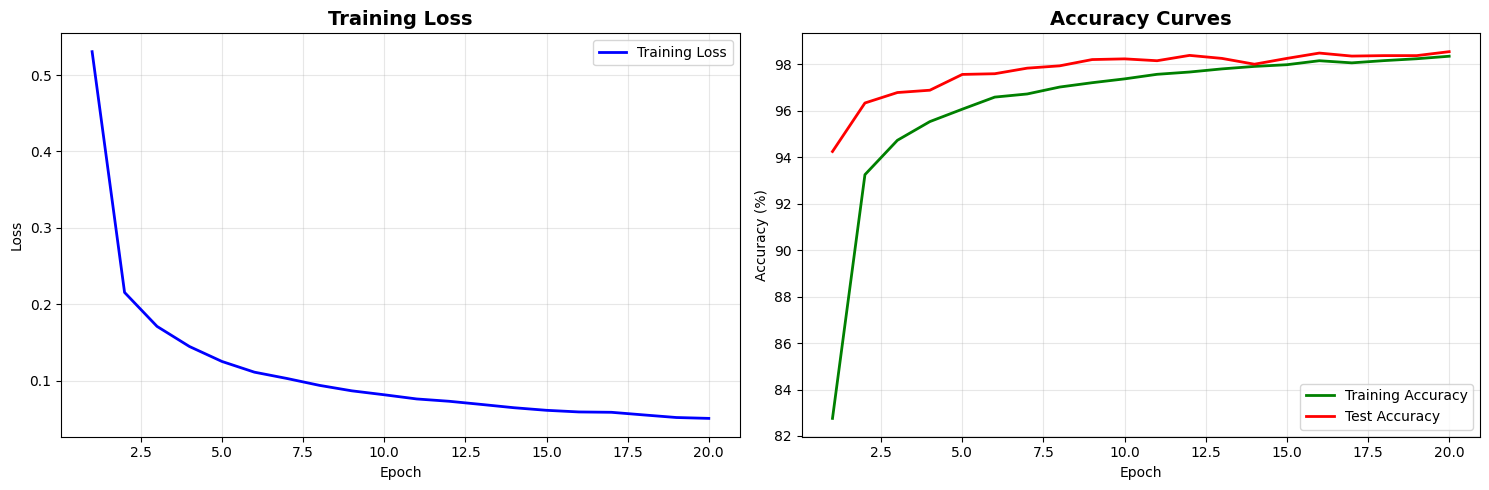

🔍 Sample Predictions with Attention Maps

Sample 1:


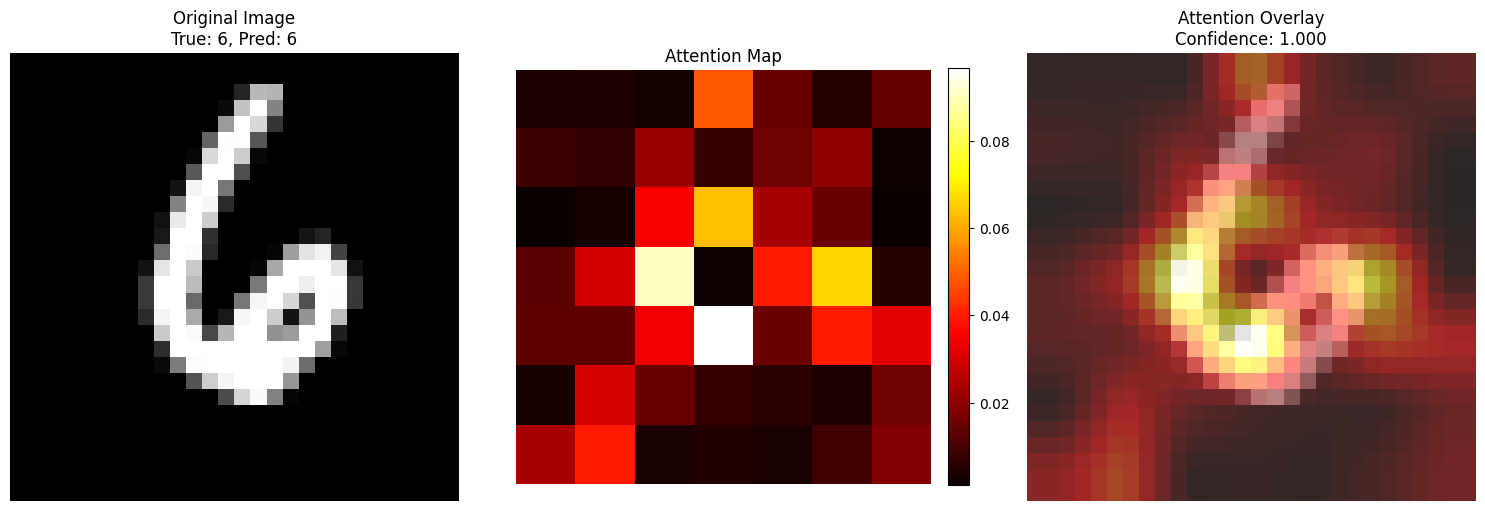


Sample 2:


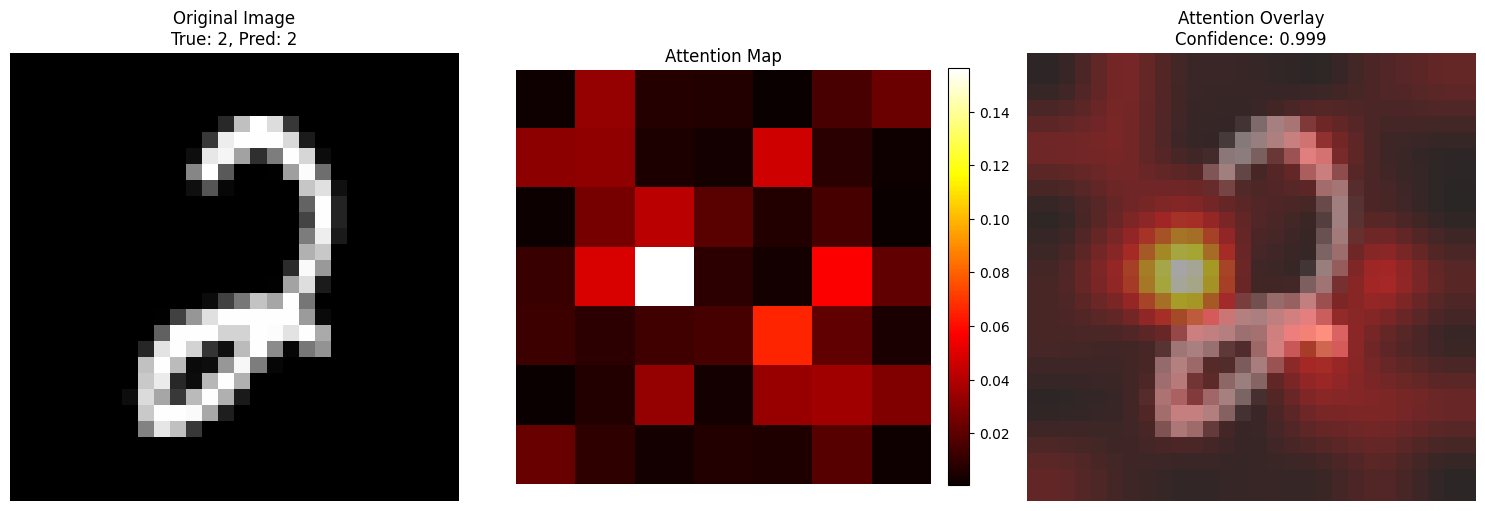


Sample 3:


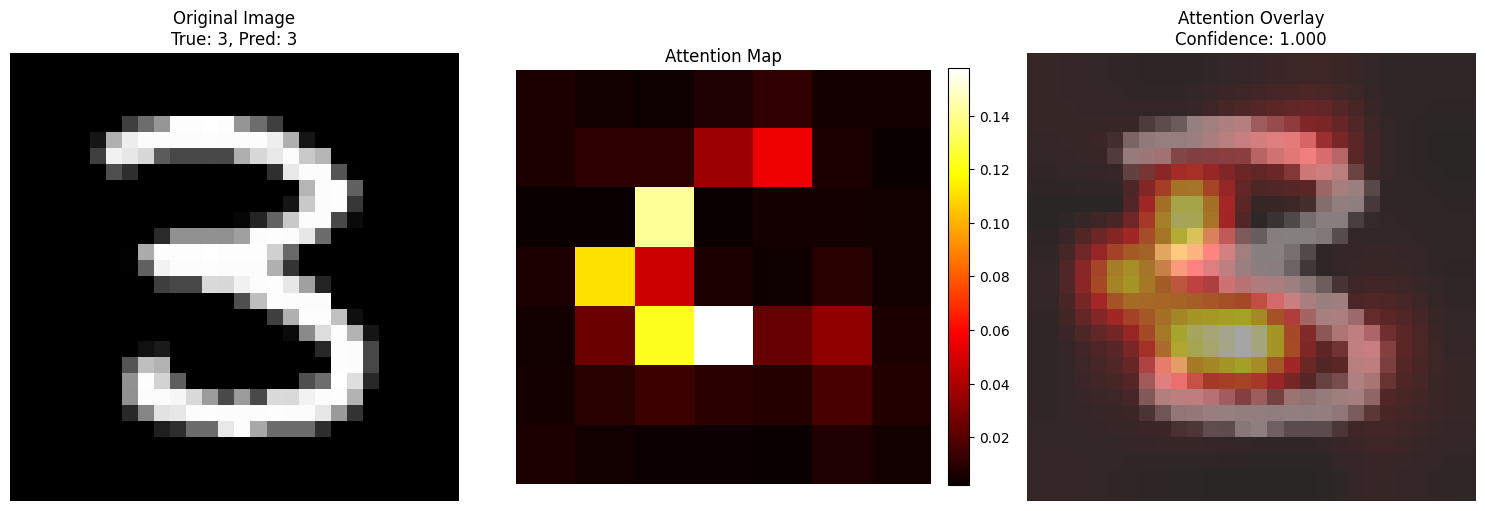


Sample 4:


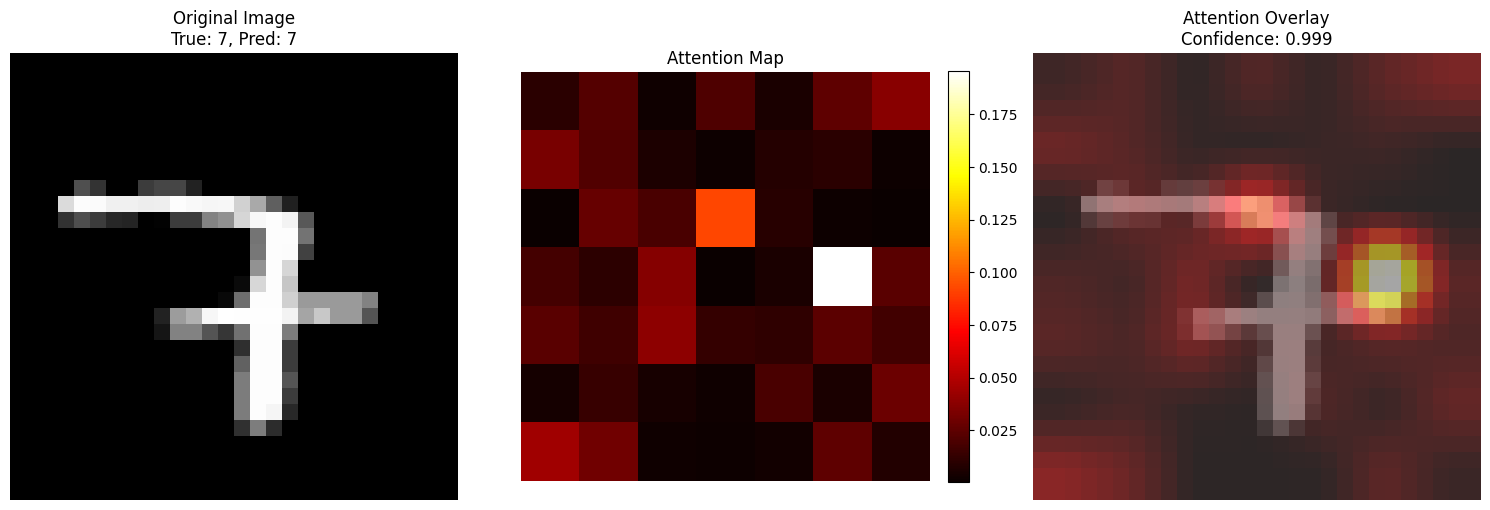


🎉 Visualization complete!


In [ ]:
# Visualize Results and Predictions
# Plot training curves
def plot_training_curves():
    """Plot training loss and accuracy curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    epochs = range(1, len(train_losses) + 1)

    # Loss plot
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.set_title('Training Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Accuracy plot
    ax2.plot(epochs, train_accuracies, 'g-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Test Accuracy', linewidth=2)
    ax2.set_title('Accuracy Curves', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves()

# Visualize attention maps
def visualize_attention(model, image, label, patch_size=4):
    """Visualize attention weights for a given image"""
    model.eval()

    with torch.no_grad():
        image_batch = image.unsqueeze(0).to(device)
        outputs, attention_weights_list = model(image_batch)

        # Get prediction
        probabilities = F.softmax(outputs, dim=1)
        predicted_class = outputs.argmax(dim=1).item()
        confidence = probabilities.max().item()

    # Denormalize image for display
    img_display = image.squeeze() * 0.3081 + 0.1307

    # Use attention from the last layer
    attention = attention_weights_list[-1][0]  # First sample, last layer

    # Average attention across heads and get attention to patches (excluding class token)
    patch_attention = attention.mean(dim=0)[0, 1:].cpu()  # Class token attention to patches

    # Reshape attention to spatial dimensions
    num_patches_per_side = int(math.sqrt(len(patch_attention)))
    attention_map = patch_attention.reshape(num_patches_per_side, num_patches_per_side)

    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(img_display, cmap='gray')
    axes[0].set_title(f'Original Image\nTrue: {label}, Pred: {predicted_class}')
    axes[0].axis('off')

    # Attention map
    im1 = axes[1].imshow(attention_map, cmap='hot', interpolation='nearest')
    axes[1].set_title('Attention Map')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # Overlay attention on image
    # Resize attention map to match image size
    attention_resized = F.interpolate(
        attention_map.unsqueeze(0).unsqueeze(0),
        size=(28, 28),
        mode='bilinear',
        align_corners=False
    ).squeeze()

    axes[2].imshow(img_display, cmap='gray', alpha=0.7)
    axes[2].imshow(attention_resized, cmap='hot', alpha=0.5)
    axes[2].set_title(f'Attention Overlay\nConfidence: {confidence:.3f}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize predictions with attention
def show_sample_predictions(model, test_dataset, num_samples=6):
    """Show sample predictions with attention maps"""
    print("🔍 Sample Predictions with Attention Maps")
    print("=" * 50)

    # Get some test samples
    indices = np.random.choice(len(test_dataset), num_samples, replace=False)

    for i, idx in enumerate(indices):
        print(f"\nSample {i+1}:")
        image, label = test_dataset[idx]
        visualize_attention(model, image, label)

show_sample_predictions(model, test_dataset, num_samples=4)

# Compare with wrong predictions
def show_wrong_predictions(model, test_loader, device, num_samples=4):
    """Show examples where the model made wrong predictions"""
    model.eval()
    wrong_examples = []

    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            outputs, attention_weights = model(data)
            _, predicted = outputs.max(1)

            # Find wrong predictions
            wrong_mask = predicted != targets
            if wrong_mask.any():
                wrong_indices = torch.where(wrong_mask)[0]
                for idx in wrong_indices:
                    if len(wrong_examples) < num_samples:
                        wrong_examples.append({
                            'image': data[idx].cpu(),
                            'true_label': targets[idx].item(),
                            'predicted_label': predicted[idx].item(),
                            'confidence': F.softmax(outputs[idx], dim=0).max().item()
                        })

    print("\n❌ Wrong Predictions Analysis")
    print("=" * 40)

    for i, example in enumerate(wrong_examples):
        print(f"\nWrong Prediction {i+1}:")
        visualize_attention(model, example['image'], example['true_label'])
        print(f"True: {example['true_label']}, Predicted: {example['predicted_label']}, "
              f"Confidence: {example['confidence']:.3f}")

if len([p for p in predictions if p != targets[np.where(predictions == p)[0][0]]]) > 0:
    show_wrong_predictions(model, test_loader, device, num_samples=2)

print("\n🎉 Visualization complete!")